In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import joblib
import shap
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Load Data

In [ ]:
X_train = pd.read_csv("./Working Data/x_train.csv")
X_test  = pd.read_csv("./Working Data/x_test.csv")
y_train = pd.read_csv("./Working Data/y_train.csv").squeeze()  # squeeze to Series
y_test  = pd.read_csv("./Working Data/y_test.csv").squeeze()

Evaluation Helper Function

In [ ]:
# takes any trained model and prints
# all required metrics, then plots the confusion matrix.
def evaluate(name, model, X, y):
    preds = model.predict(X)
    acc  = accuracy_score(y, preds)
    prec = precision_score(y, preds)
    rec  = recall_score(y, preds)
    f1   = f1_score(y, preds)
    cm   = confusion_matrix(y, preds)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}  (of predicted positives, how many were right)")
    print(f"  Recall   : {rec:.4f}  (of actual positives, how many did we catch)")
    print(f"  F1 Score : {f1:.4f}  (harmonic mean of precision & recall)")
    print(f"\n  Confusion Matrix:")
    print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
    print(f"\n  Best params: {model.best_params_}")

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    plt.tight_layout()
    plt.savefig(f"./Working Data/Summary/cm_{name.replace(' ', '_')}.png", dpi=150)
    plt.close()

    return {"Model": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "TN": cm[0,0], "FP": cm[0,1],
            "FN": cm[1,0], "TP": cm[1,1]}

In [ ]:
results = []

Logistic Regression

In [ ]:
print("Training Logistic Regression...")

lr_params = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    cv=5,           # 5-fold cross-validation
    scoring='accuracy',   # optimise for accuracy
    n_jobs=-1
)
lr.fit(X_train, y_train)
results.append(evaluate("Logistic Regression", lr, X_test, y_test))

SVM

In [ ]:
print("Training SVM...")

svm_params = {
    'C':      [0.1, 1, 10, 100],   # regularisation strength — controls the
                                    # margin width vs. misclassification trade-off
    'kernel': ['linear', 'rbf']     # linear = straight boundary, rbf = curved
                                    # boundary for non-linearly separable data
}

svm = GridSearchCV(
    SVC(probability=True,    # needed so the model can output confidence scores,
                             # not just hard labels — required by some downstream steps
        random_state=42),    # makes results reproducible across runs
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svm.fit(X_train, y_train)
results.append(evaluate("SVM", svm, X_test, y_test))

Decision Tree

In [ ]:
print("Training Decision Tree...")

dt_params = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10, 20]
}

dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
dt.fit(X_train, y_train)
results.append(evaluate("Decision Tree", dt, X_test, y_test))

Random Forest

In [ ]:
print("Training Random Forest...")

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 10, None]
}

rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test))

XGBoost

In [ ]:
print("Training XGBoost...")

xgb_params = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth':     [3, 5, 7]
}

xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost", xgb, X_test, y_test))

K-NN

In [ ]:
print("Training KNN...")

knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric':      ['euclidean', 'manhattan']
}

knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn.fit(X_train, y_train)
results.append(evaluate("KNN", knn, X_test, y_test))

In [ ]:
models = {"Logistic Regression": lr.best_estimator_,"Support Vector Machine": svm.best_estimator_, "Decision Tree": dt.best_estimator_, "Random Forest": rf.best_estimator_, "XGBoost": xgb.best_estimator_, "KNN": knn.best_estimator_}

RFECV


Running RFECV for Logistic Regression...
Optimal number of features for Logistic Regression: 10
Selected features for Logistic Regression: ['Gender', 'Chest pain type', 'BP', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Number of vessels fluro', 'Thallium', 'smoking_status_never smoked']
Optimal number of features: 10

Selected features:
  ✓ Gender
  ✓ Chest pain type
  ✓ BP
  ✓ EKG results
  ✓ Max HR
  ✓ Exercise angina
  ✓ ST depression
  ✓ Number of vessels fluro
  ✓ Thallium
  ✓ smoking_status_never smoked

Dropped features:
  ✗ Age
  ✗ Cholesterol
  ✗ FBS over 120
  ✗ Slope of ST
  ✗ work_type_Govt_job
  ✗ work_type_Private
  ✗ work_type_Self-employed
  ✗ work_type_Unknown
  ✗ smoking_status_Unknown
  ✗ smoking_status_formerly smoked
  ✗ smoking_status_smokes


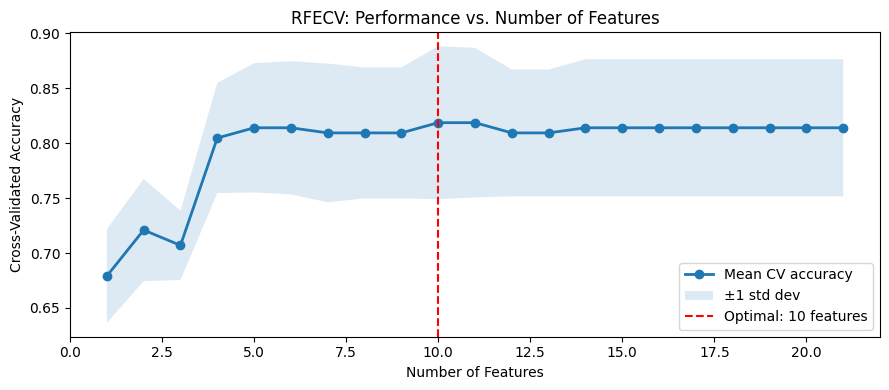


Running RFECV for Support Vector Machine...
Optimal number of features for Support Vector Machine: 14
Selected features for Support Vector Machine: ['Age', 'Gender', 'Chest pain type', 'BP', 'Max HR', 'Exercise angina', 'ST depression', 'Number of vessels fluro', 'Thallium', 'work_type_Govt_job', 'work_type_Unknown', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_smokes']
Optimal number of features: 14

Selected features:
  ✓ Age
  ✓ Gender
  ✓ Chest pain type
  ✓ BP
  ✓ Max HR
  ✓ Exercise angina
  ✓ ST depression
  ✓ Number of vessels fluro
  ✓ Thallium
  ✓ work_type_Govt_job
  ✓ work_type_Unknown
  ✓ smoking_status_Unknown
  ✓ smoking_status_formerly smoked
  ✓ smoking_status_smokes

Dropped features:
  ✗ Cholesterol
  ✗ FBS over 120
  ✗ EKG results
  ✗ Slope of ST
  ✗ work_type_Private
  ✗ work_type_Self-employed
  ✗ smoking_status_never smoked


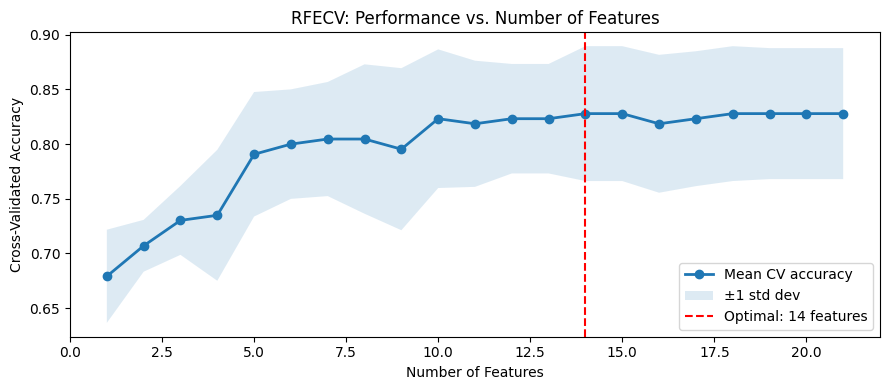


Running RFECV for Decision Tree...
Optimal number of features for Decision Tree: 3
Selected features for Decision Tree: ['Chest pain type', 'Number of vessels fluro', 'Thallium']
Optimal number of features: 3

Selected features:
  ✓ Chest pain type
  ✓ Number of vessels fluro
  ✓ Thallium

Dropped features:
  ✗ Age
  ✗ Gender
  ✗ BP
  ✗ Cholesterol
  ✗ FBS over 120
  ✗ EKG results
  ✗ Max HR
  ✗ Exercise angina
  ✗ ST depression
  ✗ Slope of ST
  ✗ work_type_Govt_job
  ✗ work_type_Private
  ✗ work_type_Self-employed
  ✗ work_type_Unknown
  ✗ smoking_status_Unknown
  ✗ smoking_status_formerly smoked
  ✗ smoking_status_never smoked
  ✗ smoking_status_smokes


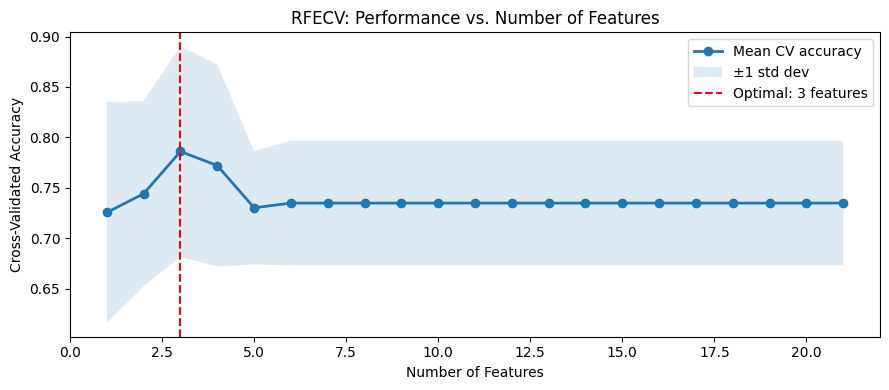


Running RFECV for Random Forest...
Optimal number of features for Random Forest: 14
Selected features for Random Forest: ['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'work_type_Unknown', 'smoking_status_formerly smoked']
Optimal number of features: 14

Selected features:
  ✓ Age
  ✓ Gender
  ✓ Chest pain type
  ✓ BP
  ✓ Cholesterol
  ✓ EKG results
  ✓ Max HR
  ✓ Exercise angina
  ✓ ST depression
  ✓ Slope of ST
  ✓ Number of vessels fluro
  ✓ Thallium
  ✓ work_type_Unknown
  ✓ smoking_status_formerly smoked

Dropped features:
  ✗ FBS over 120
  ✗ work_type_Govt_job
  ✗ work_type_Private
  ✗ work_type_Self-employed
  ✗ smoking_status_Unknown
  ✗ smoking_status_never smoked
  ✗ smoking_status_smokes


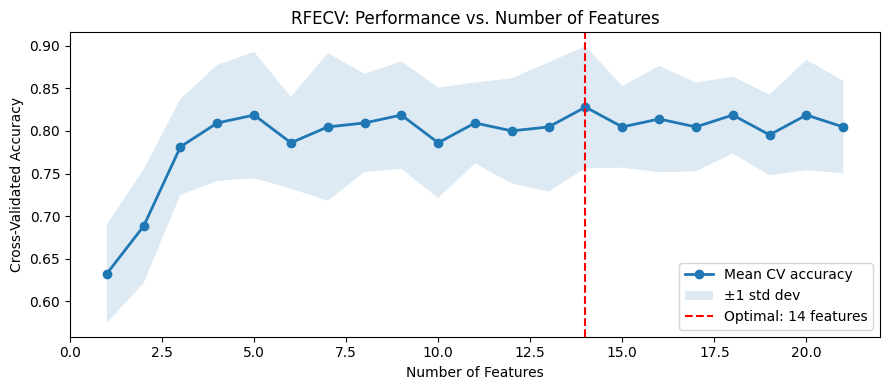


Running RFECV for XGBoost...
Optimal number of features for XGBoost: 14
Selected features for XGBoost: ['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'smoking_status_formerly smoked', 'smoking_status_never smoked']
Optimal number of features: 14

Selected features:
  ✓ Age
  ✓ Gender
  ✓ Chest pain type
  ✓ BP
  ✓ Cholesterol
  ✓ EKG results
  ✓ Max HR
  ✓ Exercise angina
  ✓ ST depression
  ✓ Slope of ST
  ✓ Number of vessels fluro
  ✓ Thallium
  ✓ smoking_status_formerly smoked
  ✓ smoking_status_never smoked

Dropped features:
  ✗ FBS over 120
  ✗ work_type_Govt_job
  ✗ work_type_Private
  ✗ work_type_Self-employed
  ✗ work_type_Unknown
  ✗ smoking_status_Unknown
  ✗ smoking_status_smokes


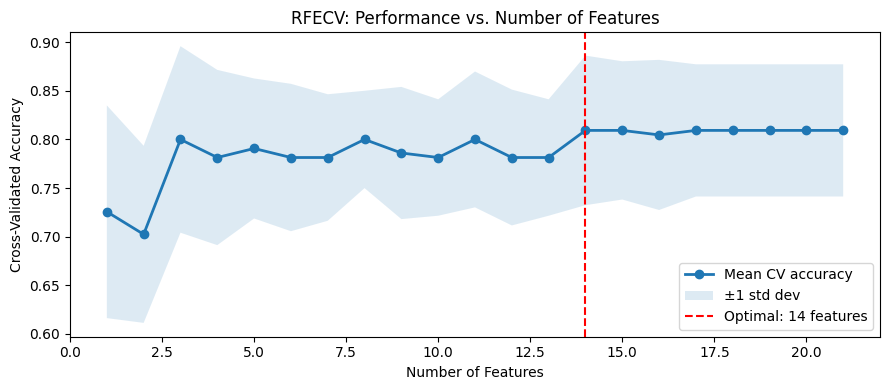

In [119]:
# ── Step 1: Define the base estimator ─────────────────────────────────────────
# RFECV needs a model to train and evaluate at each step.
# Using a fixed model here — not another GridSearchCV — keeps computation manageable.

# ── Step 2: Define the cross-validation strategy ──────────────────────────────
# StratifiedKFold preserves the class ratio (disease vs. no disease) in every
# fold. This matters on medical data where classes may be imbalanced — plain
# KFold could accidentally put most disease cases in one fold.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Step 3: Build RFECV ────────────────────────────────────────────────────────
for name, model in models.items():
    if name == "KNN":
        continue
    print(f"\nRunning RFECV for {name}...")
    rfecv = RFECV(
        estimator=model,
        step=1,               # remove 1 feature at a time — slower but more precise.
                            # You can set step=2 or step=0.1 (10%) to speed things up
                            # if you have many features.
        cv=cv_strategy,
        scoring='accuracy',   # the metric used to judge each feature subset.
                            # swap for 'f1' or 'recall' if those matter more to you.
        min_features_to_select=1,  # don't stop early — let it evaluate all the way down
        n_jobs=-1             # parallelise across CPU cores
    )

    rfecv.fit(X_train, y_train)
    print(f"Optimal number of features for {name}: {rfecv.n_features_}")
    print(f"Selected features for {name}: {X_train.columns[rfecv.support_].tolist()}")

    # ── Step 4: See what was selected ─────────────────────────────────────────────
    print(f"Optimal number of features: {rfecv.n_features_}")
    print(f"\nSelected features:")
    selected = X_train.columns[rfecv.support_]
    for feature in selected:
        print(f"  ✓ {feature}")

    print(f"\nDropped features:")
    dropped = X_train.columns[~rfecv.support_]
    for feature in dropped:
        print(f"  ✗ {feature}")

    # ── Step 5: Plot the performance curve ────────────────────────────────────────
    # This shows you the cross-validated accuracy at each feature count.
    # The peak of this curve is where RFECV chose to stop.
    # Looking at the *shape* is just as important as the peak —
    # a flat plateau tells you many features are redundant;
    # a sharp cliff tells you a small set of features carries most of the signal.

    mean_scores = rfecv.cv_results_['mean_test_score']
    std_scores  = rfecv.cv_results_['std_test_score']
    feature_counts = range(1, len(mean_scores) + 1)

    plt.figure(figsize=(9, 4))
    plt.plot(feature_counts, mean_scores, marker='o', linewidth=2, label='Mean CV accuracy')

    # Shaded band shows ±1 standard deviation across folds —
    # a wide band means the result is unstable (high variance across folds)
    plt.fill_between(
        feature_counts,
        mean_scores - std_scores,
        mean_scores + std_scores,
        alpha=0.15,
        label='±1 std dev'
    )

    plt.axvline(
        x=rfecv.n_features_,
        color='red', linestyle='--',
        label=f'Optimal: {rfecv.n_features_} features'
    )

    plt.xlabel('Number of Features')
    plt.ylabel('Cross-Validated Accuracy')
    plt.title('RFECV: Performance vs. Number of Features')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── Step 6: Apply the selection to both sets ──────────────────────────────────
    # rfecv.transform() keeps only the columns that were selected.
    # We apply the same mask to both train and test — never refit on test data.
    X_train_rfe = rfecv.transform(X_train)
    X_test_rfe  = rfecv.transform(X_test)

    # If you want to keep column names (useful for SHAP later), do it this way instead:
    X_train_rfe = X_train[selected]
    X_test_rfe  = X_test[selected]

    # ── Step 7: Retrain your full pipeline on the reduced feature set ──────────────
    # Now you can plug X_train_rfe and X_test_rfe into your existing model cells
    # exactly as before. Run GridSearchCV again on the reduced set —
    # the optimal hyperparameters may shift slightly with fewer features.

#     results = {}

# for name, model in models.items():
#     print(f"جاري العمل على موديل: {name}...")
    
#     # تعريف الـ RFECV لكل موديل
#     selector = RFECV(estimator=model, step=1, cv=5)
    
#     # التدريب
#     selector.fit(X, y)
    
#     # تخزين النتائج عشان تقارن بينهم
#     results[name] = {
#         "n_features": selector.n_features_,
#         "selected_features": selector.support_,
#         "ranking": selector.ranking_
#     }
    
#     print(f"تم! عدد الميزات المختارة بواسطة {name}: {selector.n_features_}")
#     print("-" * 30)


Summary

In [ ]:
print("\n\n" + "="*55)
print("  MODEL COMPARISON SUMMARY")
print("="*55)

summary = pd.DataFrame(results)[["Model", "Accuracy", "Precision", "Recall", "F1"]]
summary = summary.sort_values("F1", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

summary.to_csv("./Working Data/Summary/model_summary.csv", index=False)
print("\nSummary saved to ./Working Data/Summary/model_summary.csv")
print("Confusion matrix plots saved to ./Working Data/Summary/")

Save Model

In [ ]:
max_acc = 0
best_model_name = ""
for name in results:
    if name["Accuracy"] > max_acc:
        max_acc = name["Accuracy"]
        best_model_name = name["Model"]
print(f"\nBest model: {best_model_name} with accuracy: {max_acc:.4f}")
best_model = models[best_model_name]
joblib.dump(best_model, './Models/heart_disease_model.pkl')

Feature Importance

In [ ]:
try:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    # For binary classification, TreeExplainer returns a list: [class_0, class_1]
    # We plot class 1 (Disease = positive class) — that's the medically meaningful side
    plot_values = shap_values[1] if isinstance(shap_values, list) else shap_values

except Exception:
    # Fallback for non-tree models — pass a background sample so SHAP can
    # estimate how much each feature moves the prediction away from the baseline
    explainer   = shap.Explainer(best_model.predict, X_train)
    shap_values = explainer(X_test)
    plot_values = shap_values.values

shap.summary_plot(
    plot_values,
    X_test,
    feature_names=X_test.columns.tolist(),   # use actual column names, not indices
    max_display=10,                         # show top 10 most important features
    plot_type="dot"                           # "dot" shows both direction and magnitude;
                                             # swap for "bar" if you just want ranking
)

In [ ]:
# ─────────────────────────────────────────────
# MODEL 1 — LOGISTIC REGRESSION
#
# How it works: finds a linear boundary in feature
# space that best separates the two classes. The
# output is a probability, which is then thresholded
# at 0.5 to produce a class label.
#
# Hyperparameters we vary:
#
# C — the inverse of regularisation strength.
#   A small C means strong regularisation, which
#   shrinks coefficients toward zero and prevents
#   overfitting. A large C gives the model more
#   freedom to fit the training data.
#
# solver — the optimisation algorithm used to find
#   the best coefficients. 'lbfgs' and 'liblinear'
#   are both good for small datasets like this one.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 2 — DECISION TREE
#
# How it works: recursively splits the data on the
# feature/threshold that best separates the classes,
# forming a tree of if/else rules. Very interpretable
# — you can literally follow the path from root to
# leaf to understand any individual prediction.
#
# Hyperparameters we vary:
#
# max_depth — how deep the tree is allowed to grow.
#   A shallow tree underfits (misses patterns); a
#   very deep tree overfits (memorises training data).
#
# min_samples_split — the minimum number of samples
#   a node must have before it can be split further.
#   Higher values make the tree more conservative and
#   less likely to create splits that only explain
#   one or two training examples.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 3 — RANDOM FOREST
#
# How it works: builds many decision trees, each
# trained on a random subset of rows (bagging) and
# a random subset of features at each split. The
# final prediction is a majority vote across all
# trees. This reduces the variance that single
# decision trees are prone to.
#
# Hyperparameters we vary:
#
# n_estimators — the number of trees in the forest.
#   More trees generally means better performance up
#   to a point, after which returns diminish. More
#   trees also means longer training time.
#
# max_depth — same concept as in the Decision Tree,
#   but now applied to each individual tree in the
#   forest. Shallower trees mean more bias but less
#   variance — the ensemble compensates for the bias.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 4 (BONUS) — XGBOOST
#
# How it works: like Random Forest, XGBoost builds
# many trees — but instead of building them in
# parallel independently, it builds them sequentially.
# Each new tree focuses on correcting the errors the
# previous trees made. This is called gradient
# boosting, and it tends to produce very accurate
# results on structured/tabular data.
#
# Hyperparameters we vary:
#
# n_estimators — number of boosting rounds (trees).
#   Unlike Random Forest, more rounds can lead to
#   overfitting, so this needs to be tuned carefully.
#
# learning_rate — how much each new tree's contribution
#   is scaled down before being added to the ensemble.
#   A lower rate means each tree contributes less,
#   requiring more trees to reach the same performance
#   — but typically generalises better.
#
# max_depth — depth of each individual tree. XGBoost
#   trees are typically kept shallow (3-6) because
#   the boosting process itself adds complexity.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# MODEL 5 (BONUS) — K-NEAREST NEIGHBORS (KNN)
#
# How it works: no training in the traditional sense.
# Instead, when predicting a new patient, KNN finds
# the k most similar patients in the training set
# (using distance in feature space) and takes a
# majority vote of their labels. It's entirely
# instance-based — the "model" is just the training
# data itself.
#
# This is the primary reason StandardScaler was applied
# in preprocessing. Without scaling, Age (range ~50)
# and Cholesterol (range ~200+) would completely
# dominate the distance calculation, drowning out
# binary features like Gender or Exercise Angina.
# Scaling puts all features on equal footing.
#
# Hyperparameters we vary:
#
# n_neighbors (k) — how many neighbours vote on the
#   prediction. Small k = sensitive to noise (overfits);
#   large k = smoother boundary (underfits). Finding
#   the right k is the central tuning challenge in KNN.
#
# metric — the distance function used to measure
#   similarity. 'euclidean' is straight-line distance.
#   'manhattan' sums absolute differences dimension by
#   dimension. On high-dimensional data, manhattan
#   often generalises better than euclidean.
# ─────────────────────────────────────────────



# ─────────────────────────────────────────────
# SUMMARY TABLE
#
# A side-by-side comparison of all models makes it
# easy to identify which performed best and where
# each model's strengths and weaknesses lie.
# ─────────────────────────────────────────────